In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, GRU, Dense, Dropout, Attention, GlobalAveragePooling1D, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

In [ ]:
base_path = "/content/drive/MyDrive/dataset"

all_sequences = []
all_labels = []

TIME_STEPS = 100
STEP = 20  # overlap

def find_column(cols, keywords):
    for col in cols:
        for key in keywords:
            if key in col.lower():
                return col
    return None

for rating in range(1, 6):
    folder_path = os.path.join(base_path, f"{rating}_star")

    for file in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file)

        try:
            if file.endswith(".csv"):
                df = pd.read_csv(file_path)
            elif file.endswith(".xlsx"):
                df = pd.read_excel(file_path)
            else:
                continue

            df.columns = df.columns.str.strip()
            cols = df.columns.tolist()

            ax = find_column(cols, ['x_acc','acc_x'])
            ay = find_column(cols, ['y_acc','acc_y'])
            az = find_column(cols, ['z_acc','acc_z'])
            gx = find_column(cols, ['x_gyro','gyro_x'])
            gy = find_column(cols, ['y_gyro','gyro_y'])
            gz = find_column(cols, ['z_gyro','gyro_z'])

            if None in [ax, ay, az, gx, gy, gz]:
                continue

            df = df[[ax, ay, az, gx, gy, gz]]
            df.columns = ['ax','ay','az','gx','gy','gz']

            # remove zero rows
            df = df[
                ~(
                    (df[['ax','ay','az']] == 0).all(axis=1) |
                    (df[['gx','gy','gz']] == 0).all(axis=1)
                 )
            ]

            # smoothing
            df = df.rolling(window=3).mean().dropna()

            # features
            df['acc_mag'] = np.sqrt(df['ax']**2 + df['ay']**2 + df['az']**2)
            df['gyro_mag'] = np.sqrt(df['gx']**2 + df['gy']**2 + df['gz']**2)

            df['jerk'] = np.sqrt(
                np.diff(df['ax'], prepend=df['ax'].iloc[0])**2 +
                np.diff(df['ay'], prepend=df['ay'].iloc[0])**2 +
                np.diff(df['az'], prepend=df['az'].iloc[0])**2
            )

            df['acc_var'] = df[['ax','ay','az']].rolling(5).var().mean(axis=1)
            df['gyro_var'] = df[['gx','gy','gz']].rolling(5).var().mean(axis=1)

            df = df.dropna()

            data = df.values

            # create sequences
            for i in range(0, len(data) - TIME_STEPS, STEP):
                seq = data[i:i+TIME_STEPS]
                all_sequences.append(seq)
                all_labels.append(rating)

        except Exception as e:
            print("Error:", file, e)

X = np.array(all_sequences)
y = np.array(all_labels)

print("Shape:", X.shape)

Shape: (136693, 100, 11)


In [ ]:
nsamples, timesteps, features = X.shape

scaler = StandardScaler()

X = X.reshape(-1, features)
X = scaler.fit_transform(X)
X = X.reshape(nsamples, timesteps, features)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

y_train = to_categorical(y_train - 1, 5)
y_test = to_categorical(y_test - 1, 5)

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y),
    y=y
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(1.1063332119299099), 1: np.float64(1.2037072912997535), 2: np.float64(0.837451370807168), 3: np.float64(0.7590681919147045), 4: np.float64(1.3265369498762676)}


In [ ]:
from tensorflow.keras.layers import GRU

In [ ]:
input_layer = Input(shape=(TIME_STEPS, X.shape[2]))

x = Bidirectional(GRU(128, return_sequences=True))(input_layer)
x = Dropout(0.3)(x)

x = Bidirectional(GRU(64, return_sequences=True))(x)

x = Attention()([x, x])

x = GlobalAveragePooling1D()(x)

x = Dense(64, activation='relu')(x)
x = Dropout(0.4)(x)

output = Dense(5, activation='softmax')(x)

model = Model(inputs=input_layer, outputs=output)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 100, 11)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 100, 256)  │    108,288 │ input_layer[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 100, 256)  │          0 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 100, 128)  │    123,648 │ dropout[0][0]     │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 100, 128)  │          0 │ bidirectional_1[… │
│ (Attention)         │                   │            │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ attention[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      8,256 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 5)         │        325 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 240,517 (939.52 KB)

 Trainable params: 240,517 (939.52 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
early_stop = EarlyStopping(patience=4, restore_best_weights=True)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2
)

history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, lr_scheduler],
    class_weight=class_weights
)

Epoch 1/15
3418/3418 ━━━━━━━━━━━━━━━━━━━━ 87s 23ms/step - accuracy: 0.6295 - loss: 0.8864 - val_accuracy: 0.7616 - val_loss: 0.5953 - learning_rate: 0.0010
Epoch 2/15
3418/3418 ━━━━━━━━━━━━━━━━━━━━ 79s 23ms/step - accuracy: 0.7723 - loss: 0.5534 - val_accuracy: 0.8051 - val_loss: 0.4751 - learning_rate: 0.0010
Epoch 3/15
3418/3418 ━━━━━━━━━━━━━━━━━━━━ 82s 23ms/step - accuracy: 0.8149 - loss: 0.4501 - val_accuracy: 0.8383 - val_loss: 0.3974 - learning_rate: 0.0010
Epoch 4/15
3418/3418 ━━━━━━━━━━━━━━━━━━━━ 82s 23ms/step - accuracy: 0.8360 - loss: 0.3942 - val_accuracy: 0.8536 - val_loss: 0.3511 - learning_rate: 0.0010
Epoch 5/15
3418/3418 ━━━━━━━━━━━━━━━━━━━━ 79s 23ms/step - accuracy: 0.8524 - loss: 0.3547 - val_accuracy: 0.8561 - val_loss: 0.3411 - learning_rate: 0.0010
Epoch 6/15
3418/3418 ━━━━━━━━━━━━━━━━━━━━ 79s 23ms/step - accuracy: 0.8630 - loss: 0.3259 - val_accuracy: 0.8711 - val_loss: 0.3149 - learning_rate: 0.0010
Epoch 7/15
3418/3418 ━━━━━━━━━━━━━━━━━━━━ 82s 23ms/step - accura

In [10]:
loss, acc = model.evaluate(X_test, y_test)
print("Accuracy:", acc)

855/855 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8960 - loss: 0.2523
Accuracy: 0.8959727883338928


In [11]:
gru_history = history

In [12]:
pred = model.predict(X_test)
pred_classes = np.argmax(pred, axis=1) + 1

def driving_score(p):
    return p * 20   # 1→20, 5→100

scores = [driving_score(p) for p in pred_classes]

print(scores[:10])

855/855 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step
[np.int64(60), np.int64(20), np.int64(100), np.int64(80), np.int64(100), np.int64(60), np.int64(20), np.int64(80), np.int64(80), np.int64(20)]


In [13]:
from sklearn.metrics import classification_report, confusion_matrix

true = np.argmax(y_test, axis=1) + 1

print(confusion_matrix(true, pred_classes))
print(classification_report(true, pred_classes))

[[4714    6   15   15  186]
 [ 240 4377   37   21   57]
 [ 403   39 5706  120  171]
 [ 577   43  136 6143  328]
 [ 429    5    4   12 3555]]
              precision    recall  f1-score   support

           1       0.74      0.96      0.83      4936
           2       0.98      0.92      0.95      4732
           3       0.97      0.89      0.93      6439
           4       0.97      0.85      0.91      7227
           5       0.83      0.89      0.86      4005

    accuracy                           0.90     27339
   macro avg       0.90      0.90      0.89     27339
weighted avg       0.91      0.90      0.90     27339



In [14]:
def driver_type(label):
    mapping = {
        1: "Very Rash",
        2: "Rash",
        3: "Balanced",
        4: "Safe",
        5: "Very Safe"
    }
    return mapping[label]

In [15]:
pred = model.predict(X_test)

pred_classes = np.argmax(pred, axis=1) + 1
true_classes = np.argmax(y_test, axis=1) + 1

855/855 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step


In [16]:
for i in range(10):
    print(f"Predicted: {driver_type(pred_classes[i])} | Actual: {driver_type(true_classes[i])}")

Predicted: Balanced | Actual: Safe
Predicted: Very Rash | Actual: Balanced
Predicted: Very Safe | Actual: Very Safe
Predicted: Safe | Actual: Safe
Predicted: Very Safe | Actual: Very Safe
Predicted: Balanced | Actual: Balanced
Predicted: Very Rash | Actual: Very Rash
Predicted: Safe | Actual: Safe
Predicted: Safe | Actual: Safe
Predicted: Very Rash | Actual: Very Rash


In [17]:
def driving_score(label):
    return label * 20

In [18]:
def evaluate_driver(sequence):
    seq = sequence.reshape(1, sequence.shape[0], sequence.shape[1])

    pred = model.predict(seq)

    label = np.argmax(pred) + 1
    confidence = np.max(pred)

    return {
        "Driver Type": driver_type(label),
        "Rating (1-5)": label,
        "Score (0-100)": driving_score(label),
        "Confidence": float(confidence)*100
    }

In [19]:
result = evaluate_driver(X_test[0])
print(result)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
{'Driver Type': 'Balanced', 'Rating (1-5)': np.int64(3), 'Score (0-100)': np.int64(60), 'Confidence': 85.42938828468323}


In [20]:
def explain_driver(label):
    explanations = {
        1: "Frequent sudden acceleration, harsh braking, unstable motion",
        2: "Occasional aggressive turns and speed variations",
        3: "Moderate driving with some inconsistencies",
        4: "Smooth acceleration and controlled turns",
        5: "Very stable, smooth and controlled driving behavior"
    }
    return explanations[label]

In [21]:
def full_driver_report(sequence):
    seq = sequence.reshape(1, sequence.shape[0], sequence.shape[1])

    pred = model.predict(seq)

    label = np.argmax(pred) + 1
    confidence = np.max(pred)

    return {
        "Driver Type": driver_type(label),
        "Score": driving_score(label),
        "Confidence": float(confidence),
        "Behavior": explain_driver(label)
    }

In [22]:
results = []

for i in range(len(X_test)):
    label = pred_classes[i]

    results.append({
        "Type": driver_type(label),
        "Score": driving_score(label)
    })

import pandas as pd
df_results = pd.DataFrame(results)

print(df_results.head())

        Type  Score
0   Balanced     60
1  Very Rash     20
2  Very Safe    100
3       Safe     80
4  Very Safe    100


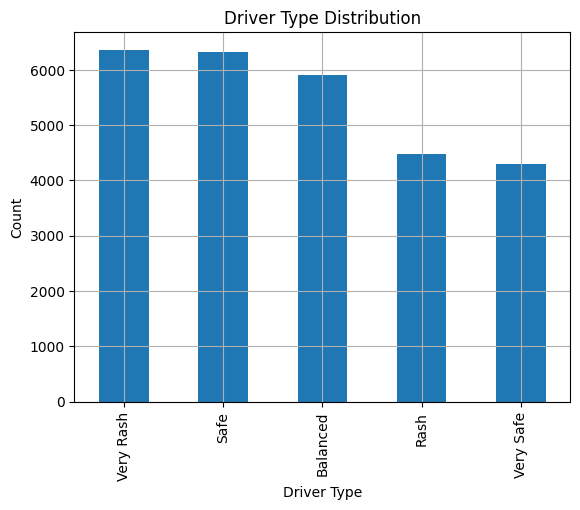

In [23]:
import matplotlib.pyplot as plt

df_results['Type'].value_counts().plot(kind='bar')

plt.title("Driver Type Distribution")
plt.xlabel("Driver Type")
plt.ylabel("Count")
plt.grid()

plt.show()

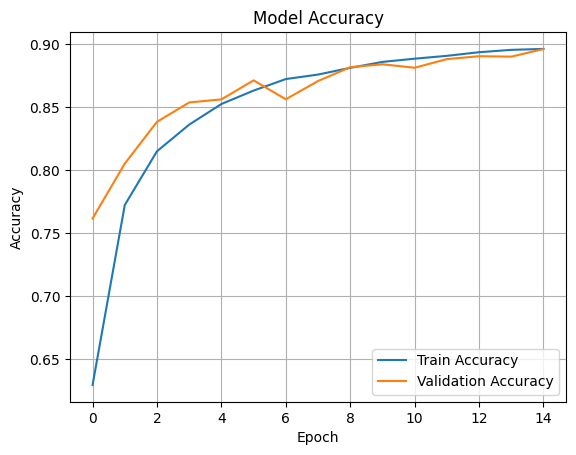

In [24]:
import matplotlib.pyplot as plt

# Accuracy plot
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train Accuracy', 'Validation Accuracy'])
plt.grid()

plt.show()

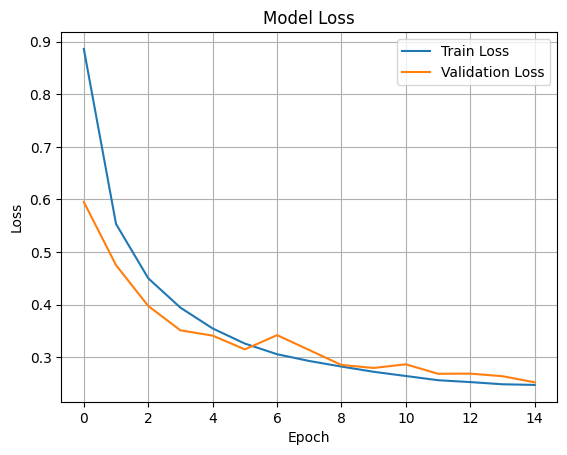

In [25]:
# Loss plot
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train Loss', 'Validation Loss'])
plt.grid()

plt.show()

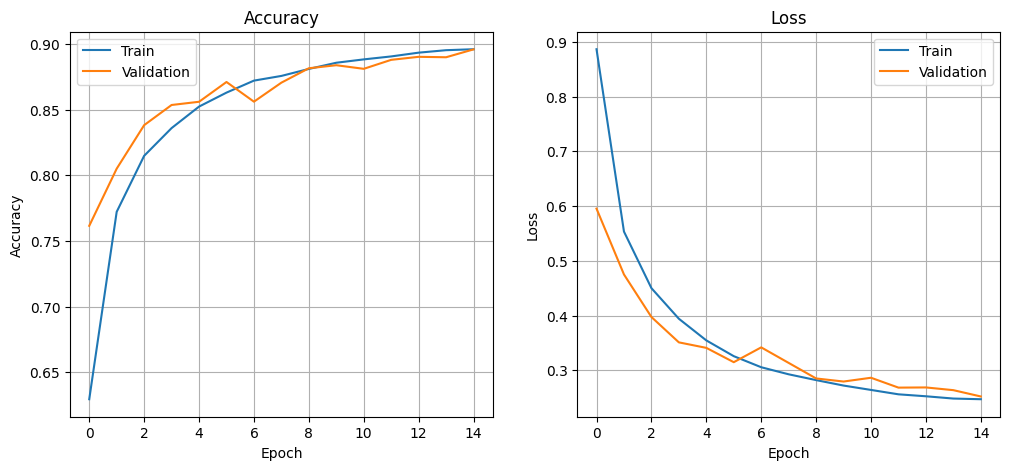

In [26]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.grid()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.grid()

plt.show()

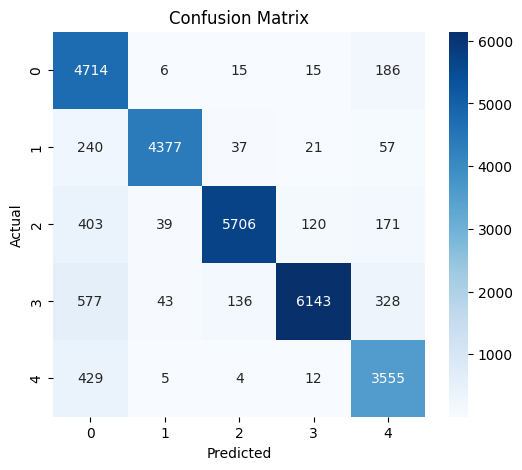

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(true, pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [ ]:
model.save("driver_behavior_model.keras")

In [ ]:
import joblib

In [ ]:
label_map = {
    1: "Very Rash",
    2: "Rash",
    3: "Balanced",
    4: "Safe",
    5: "Very Safe"
}

joblib.dump(label_map, "label_map.pkl")

['label_map.pkl']

In [ ]:
import joblib

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [ ]:
from google.colab import files

files.download("driver_behavior_model.keras")
files.download("scaler.pkl")
files.download("label_map.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from tensorflow.keras.models import load_model
import joblib

model = load_model("driver_behavior_model.keras")
scaler = joblib.load("scaler.pkl")
label_map = joblib.load("label_map.pkl")

In [48]:
import tensorflow as tf
from tensorflow.keras.layers import Layer
import numpy as np

class PositionalEncoding(Layer):
    def __init__(self, max_len, d_model):
        super().__init__()

        pos = np.arange(max_len)[:, np.newaxis]
        i = np.arange(d_model)[np.newaxis, :]

        angle_rates = 1 / np.power(10000, (2 * (i//2)) / np.float32(d_model))
        angle_rads = pos * angle_rates

        angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
        angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])

        self.pos_encoding = tf.cast(angle_rads[np.newaxis, ...], dtype=tf.float32)

    def call(self, x):
        return x + self.pos_encoding[:, :tf.shape(x)[1], :]

In [49]:
from tensorflow.keras.layers import MultiHeadAttention, LayerNormalization, Dropout, Dense

def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):

    # Multi-head attention
    x = MultiHeadAttention(num_heads=num_heads, key_dim=head_size)(inputs, inputs)
    x = Dropout(dropout)(x)
    x = LayerNormalization(epsilon=1e-6)(x + inputs)

    # Feed Forward
    ffn = Dense(ff_dim, activation="relu")(x)
    ffn = Dense(inputs.shape[-1])(ffn)

    x = Dropout(dropout)(ffn)
    return LayerNormalization(epsilon=1e-6)(x + ffn)

In [50]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

In [51]:
# Step 1: Convert to int
y_train = y_train.astype(int)
y_val   = y_val.astype(int)
y_test  = y_test.astype(int)

# If labels are 1–5 → convert to 0–4
y_train -= 1
y_val   -= 1
y_test  -= 1

# Step 3: One-hot encode
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train, 5)
y_val   = to_categorical(y_val, 5)
y_test  = to_categorical(y_test, 5)

In [52]:
print("Shape:", y_train.shape)
print("Sample:", y_train[:10])


Shape: (95685, 5)
Sample: [[0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]
 [0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0.]]


In [53]:
import numpy as np

y_train = np.argmax(y_train, axis=1)
y_val   = np.argmax(y_val, axis=1)
y_test  = np.argmax(y_test, axis=1)

In [56]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, GlobalAveragePooling1D, Dense, Dropout
from tensorflow.keras.layers import LayerNormalization
from tensorflow.keras.optimizers import Adam

def build_transformer_model(input_shape):

    inputs = Input(shape=input_shape)

    # Project features (MATCH DIMENSIONS)
    x = Dense(128)(inputs)

    # Positional Encoding (FIXED)
    x = PositionalEncoding(input_shape[0], 128)(x)

    # Transformer blocks (improved)
    for _ in range(4):
        x = transformer_encoder(
            x,
            head_size=128,      # increased
            num_heads=8,
            ff_dim=256,         # increased
            dropout=0.3
        )

    # Extra normalization (helps stability)
    x = LayerNormalization(epsilon=1e-6)(x)

    # Global pooling
    x = GlobalAveragePooling1D()(x)

    # Fully connected
    x = Dense(256, activation="relu")(x)
    x = Dropout(0.4)(x)

    x = Dense(128, activation="relu")(x)
    x = Dropout(0.3)(x)

    outputs = Dense(5, activation="softmax")(x)

    model = Model(inputs, outputs)

    return model

In [57]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

optimizer = Adam(learning_rate=0.0005)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[lr_scheduler, early_stop]
)

Epoch 1/50
1496/1496 ━━━━━━━━━━━━━━━━━━━━ 114s 25ms/step - accuracy: 0.6697 - loss: 0.7996 - val_accuracy: 0.7162 - val_loss: 0.6967 - learning_rate: 5.0000e-04
Epoch 2/50
1496/1496 ━━━━━━━━━━━━━━━━━━━━ 26s 18ms/step - accuracy: 0.7304 - loss: 0.6479 - val_accuracy: 0.7275 - val_loss: 0.6718 - learning_rate: 5.0000e-04
Epoch 3/50
1496/1496 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.7595 - loss: 0.5812 - val_accuracy: 0.7803 - val_loss: 0.5333 - learning_rate: 5.0000e-04
Epoch 4/50
1496/1496 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.7767 - loss: 0.5402 - val_accuracy: 0.7764 - val_loss: 0.5386 - learning_rate: 5.0000e-04
Epoch 5/50
1496/1496 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.7894 - loss: 0.5074 - val_accuracy: 0.7931 - val_loss: 0.5062 - learning_rate: 5.0000e-04
Epoch 6/50
1496/1496 ━━━━━━━━━━━━━━━━━━━━ 41s 17ms/step - accuracy: 0.7980 - loss: 0.4851 - val_accuracy: 0.7905 - val_loss: 0.5035 - learning_rate: 5.0000e-04
Epoch 7/50
1496/1496 ━━━━━━━━━━━━━━━━━━

In [58]:
test_loss, test_acc = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

641/641 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8846 - loss: 0.2998
Test Accuracy: 0.8846079111099243
Test Loss: 0.29980745911598206


In [60]:
from sklearn.metrics import classification_report
import numpy as np

# Predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# True labels (already integers if you used sparse)
y_true = y_test

print(classification_report(y_true, y_pred_classes))

641/641 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step
              precision    recall  f1-score   support

           0       0.77      0.93      0.84      3689
           1       0.96      0.90      0.93      3494
           2       0.95      0.87      0.91      4860
           3       0.95      0.84      0.89      5420
           4       0.78      0.91      0.84      3041

    accuracy                           0.88     20504
   macro avg       0.88      0.89      0.88     20504
weighted avg       0.90      0.88      0.89     20504



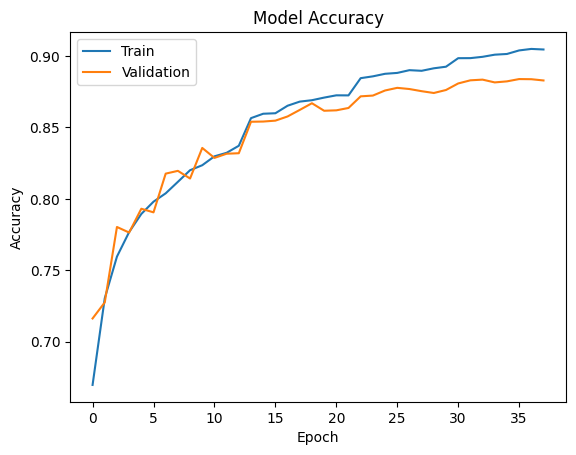

In [61]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

plt.show()

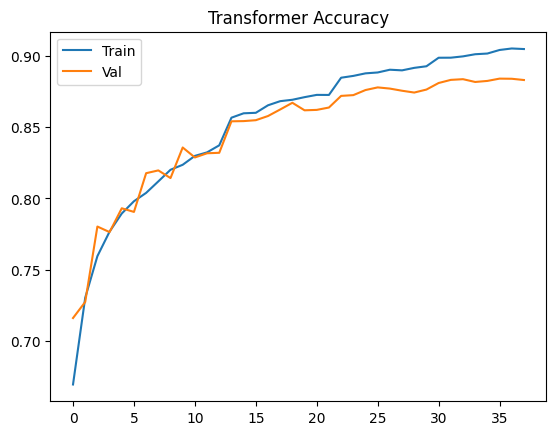

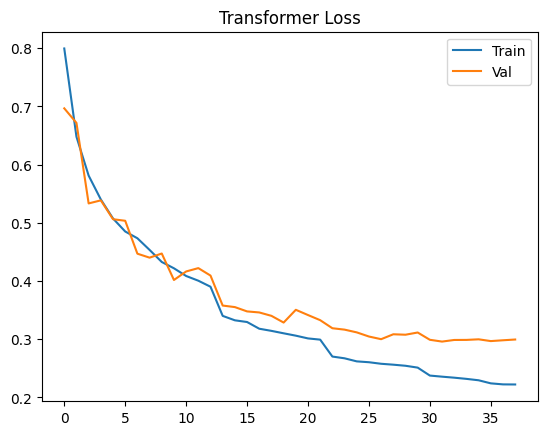

In [59]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Transformer Accuracy')
plt.legend(['Train', 'Val'])
plt.show()

# Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Transformer Loss')
plt.legend(['Train', 'Val'])
plt.show()

In [65]:
gru_history
history  # transformer

In [69]:
import numpy as np

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

641/641 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step


In [72]:
y_true = y_test

641/641 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


<Figure size 600x500 with 0 Axes>

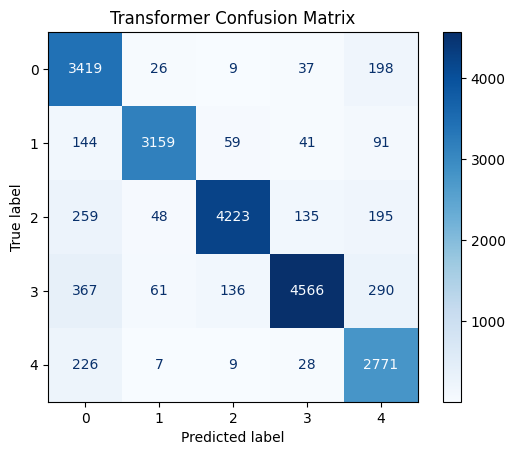

In [73]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# True labels (already correct)
y_true = y_test

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(6,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')

plt.title("Transformer Confusion Matrix")
plt.show()

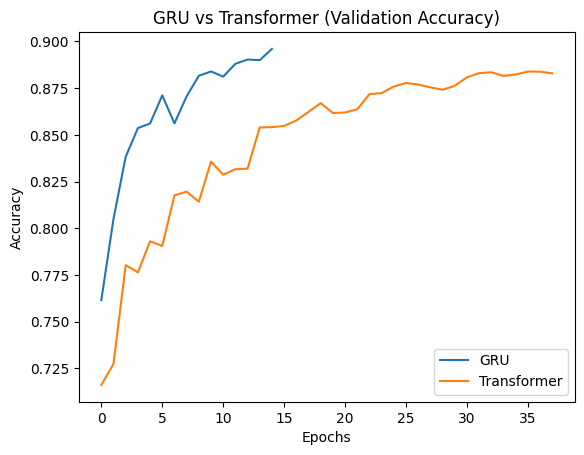

In [66]:
plt.figure()

plt.plot(gru_history.history['val_accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('GRU vs Transformer (Validation Accuracy)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['GRU', 'Transformer'])

plt.show()

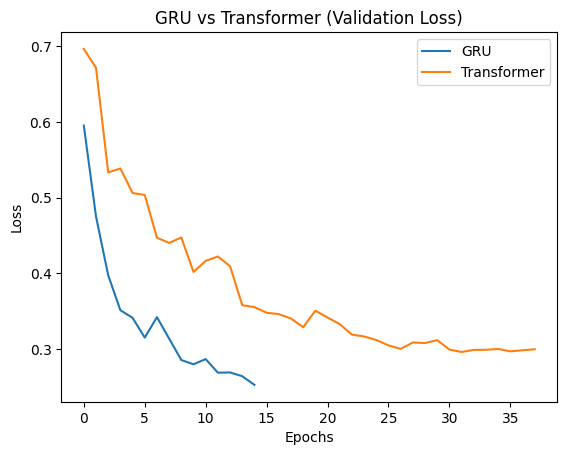

In [68]:
plt.figure()

plt.plot(gru_history.history['val_loss'])
plt.plot(history.history['val_loss'])

plt.title('GRU vs Transformer (Validation Loss)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['GRU', 'Transformer'])

plt.show()